In [8]:
import pandas as pd
import numpy as np
import fitz
import re
import nltk
import spacy

print("Libraries Imported Successfully 🚀")

Libraries Imported Successfully 🚀


In [9]:
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\prasp\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\prasp\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [10]:
!python -m spacy download en_core_web_sm

  Using cached en_core_web_sm-3.8.0-py3-none-any.whl (12.8 MB)
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')



[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
nlp = spacy.load("en_core_web_sm")

print("spaCy Ready 🚀")

spaCy Ready 🚀


 Import Required Libraries

In this section, we import the required Python libraries for data analysis and machine learning.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings("ignore")

print("Libraries Imported Successfully 🚀")

Libraries Imported Successfully 🚀


 Load the Dataset

In this section, we load the Health Insurance Cross Sell Prediction dataset into a Pandas DataFrame.

In [13]:
# Load Dataset

df = pd.read_csv("D:\\POLICYPARSER(2)\\archive (10)\\train.csv")

print("Dataset Loaded Successfully ✅")

Dataset Loaded Successfully ✅


In [ ]:
import os

print(os.path.getsize("D:\\POLICYPARSER(2)\\archive (10)\\train.csv"))

FileNotFoundError: [WinError 2] The system cannot find the file specified: 'train.csv'

In [ ]:
df = pd.read_csv("archive (10)/train.csv")

print("Dataset Loaded Successfully ✅")
df.head()

Dataset Loaded Successfully ✅


,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,3,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,4,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,5,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0


Exploratory Data Analysis (EDA)

In this step, we analyze the dataset to understand its structure, data types, missing values, and statistical information before preprocessing.

In [ ]:
# Dataset Information

print("Shape of Dataset:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Shape of Dataset: (381109, 12)

Column Names:
Index(['id', 'Gender', 'Age', 'Driving_License', 'Region_Code',
       'Previously_Insured', 'Vehicle_Age', 'Vehicle_Damage', 'Annual_Premium',
       'Policy_Sales_Channel', 'Vintage', 'Response'],
      dtype='object')

Data Types:
id                        int64
Gender                   object
Age                       int64
Driving_License           int64
Region_Code             float64
Previously_Insured        int64
Vehicle_Age              object
Vehicle_Damage           object
Annual_Premium          float64
Policy_Sales_Channel    float64
Vintage                   int64
Response                  int64
dtype: object

Missing Values:
id                      0
Gender                  0
Age                     0
Driving_License         0
Region_Code             0
Previously_Insured      0
Vehicle_Age             0
Vehicle_Damage          0
Annual_Premium          0
Policy_Sales_Channel    0
Vintage                 0
Response           

 Statistical Summary

This step provides statistical information about the numerical features such as mean, minimum, maximum, standard deviation, and quartiles.

In [ ]:


df.describe()

,id,Age,Driving_License,Region_Code,Previously_Insured,Annual_Premium,Policy_Sales_Channel,Vintage,Response
count,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000
mean,190555.000000,38.822584,0.997869,26.388807,0.458210,30564.389581,112.034295,154.347397,0.122563
std,110016.836208,15.511611,0.046110,13.229888,0.498251,17213.155057,54.203995,83.671304,0.327936
min,1.000000,20.000000,0.000000,0.000000,0.000000,2630.000000,1.000000,10.000000,0.000000
25%,95278.000000,25.000000,1.000000,15.000000,0.000000,24405.000000,29.000000,82.000000,0.000000
50%,190555.000000,36.000000,1.000000,28.000000,0.000000,31669.000000,133.000000,154.000000,0.000000
75%,285832.000000,49.000000,1.000000,35.000000,1.000000,39400.000000,152.000000,227.000000,0.000000
max,381109.000000,85.000000,1.000000,52.000000,1.000000,540165.000000,163.000000,299.000000,1.000000


 Random Data Preview

In this step, random records are displayed from the dataset to verify that the data has been loaded correctly. This helps in understanding the structure and contents of the dataset before preprocessing and model training.

In [ ]:
df.sample(5)

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
222582,222583,Female,25,1,45.0,1,< 1 Year,No,32914.0,152.0,33,0
335936,335937,Male,48,1,28.0,0,1-2 Year,Yes,49400.0,26.0,20,1
174384,174385,Male,30,1,28.0,1,< 1 Year,No,42373.0,152.0,124,0
343856,343857,Female,50,1,28.0,0,1-2 Year,Yes,44779.0,124.0,150,0
40696,40697,Male,59,0,23.0,1,1-2 Year,Yes,44503.0,26.0,233,0


# Step 5: Duplicate Data Check

In this step, we check whether the dataset contains any duplicate records. Removing duplicate values helps improve data quality and prevents the model from learning the same information multiple times.

In [ ]:
# Check Duplicate Records

duplicate_count = df.duplicated().sum()

print("Number of Duplicate Records:", duplicate_count)

Number of Duplicate Records: 0


 Missing Values Check

In this step, we check whether the dataset contains any missing (null) values. Handling missing values is important to improve data quality before model training.

In [ ]:
# Check Missing Values

missing_values = df.isnull().sum()

print("Missing Values in Each Column:")
print(missing_values)

Missing Values in Each Column:
id                      0
Gender                  0
Age                     0
Driving_License         0
Region_Code             0
Previously_Insured      0
Vehicle_Age             0
Vehicle_Damage          0
Annual_Premium          0
Policy_Sales_Channel    0
Vintage                 0
Response                0
dtype: int64


 Encode Categorical Features

In this step, categorical features are converted into numerical values using Label Encoding. Machine learning algorithms require numerical input, so this preprocessing step prepares the dataset for model training.

In [ ]:
# Import LabelEncoder

from sklearn.preprocessing import LabelEncoder

# Create LabelEncoder Object
encoder = LabelEncoder()

# Encode Categorical Columns
df["Gender"] = encoder.fit_transform(df["Gender"])
df["Vehicle_Age"] = encoder.fit_transform(df["Vehicle_Age"])
df["Vehicle_Damage"] = encoder.fit_transform(df["Vehicle_Damage"])

print("Categorical Features Encoded Successfully ✅")

Categorical Features Encoded Successfully ✅


# Step 9: Feature Selection

In this step, the dataset is divided into input features (X) and the target variable (y). The input features are used to train the model, while the target variable represents the output that the model needs to predict.

In [ ]:
# Separate Features and Target Variable

X = df.drop("Response", axis=1)
y = df["Response"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (381109, 11)
Target Shape: (381109,)


# Step 10: Split Dataset into Training and Testing Sets

In this step, the dataset is divided into training and testing sets. The training data is used to build the machine learning model, while the testing data is used to evaluate its performance on unseen data.

In [ ]:
# Import Train-Test Split

from sklearn.model_selection import train_test_split

# Split Dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Features Shape:", X_train.shape)
print("Testing Features Shape:", X_test.shape)
print("Training Labels Shape:", y_train.shape)
print("Testing Labels Shape:", y_test.shape)

Training Features Shape: (304887, 11)
Testing Features Shape: (76222, 11)
Training Labels Shape: (304887,)
Testing Labels Shape: (76222,)


# Step 11: Train Logistic Regression Model

In this step, a Logistic Regression model is trained using the training dataset. The trained model will be used to predict the target variable on unseen data.

In [ ]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

print("Logistic Regression Model Trained Successfully ✅")

Logistic Regression Model Trained Successfully ✅


# Step 12: Make Predictions

In this step, the trained model predicts the target values for the testing dataset.

In [ ]:
y_pred = lr_model.predict(X_test)

print("Prediction Completed Successfully ✅")

Prediction Completed Successfully ✅


# Step 13: Model Evaluation

In this step, the accuracy of the Logistic Regression model is calculated to evaluate its prediction performance.

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8747999265303981


# Step 14: Train Decision Tree Classifier

In this step, a Decision Tree Classifier is trained using the training dataset. Decision Trees can capture non-linear relationships and are often more powerful than Logistic Regression for complex datasets.

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Create Model
dt_model = DecisionTreeClassifier(random_state=42)

# Train Model
dt_model.fit(X_train, y_train)

# Prediction
y_pred_dt = dt_model.predict(X_test)

# Accuracy
dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.8211671171052977


# Step 15: Train Random Forest Classifier

In this step, a Random Forest Classifier is trained using multiple decision trees. It improves prediction accuracy by combining the results of several trees and reduces overfitting.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Create Model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train Model
rf_model.fit(X_train, y_train)

# Prediction
y_pred_rf = rf_model.predict(X_test)

# Accuracy
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.8705098265592611


# Step 17: Train XGBoost Classifier

In this step, an XGBoost Classifier is trained. XGBoost is an advanced ensemble learning algorithm that often provides better accuracy than traditional machine learning models.

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

# Create XGBoost Model
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

# Train Model
xgb_model.fit(X_train, y_train)

# Prediction
y_pred_xgb = xgb_model.predict(X_test)

# Accuracy
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)

print("XGBoost Accuracy:", xgb_accuracy)

XGBoost Accuracy: 0.8736847629293379


# Step 16: Hyperparameter Tuning for Random Forest

In this step, the Random Forest model is optimized by adjusting its hyperparameters. Proper tuning helps improve the model's performance and reduces overfitting.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Tuned Random Forest Model
rf_tuned = RandomForestClassifier(
    n_estimators=500,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

# Train Model
rf_tuned.fit(X_train, y_train)

# Prediction
y_pred_tuned = rf_tuned.predict(X_test)

# Accuracy
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)

print("Tuned Random Forest Accuracy:", accuracy_tuned)

Tuned Random Forest Accuracy: 0.8752459919708221


In [ ]:
# Step 17: Optimized Random Forest Model

In this step, the Random Forest model is optimized by increasing the number of decision trees and adjusting important hyperparameters. This helps improve the model's prediction performance and achieve better accuracy.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Optimized Random Forest Model
rf_model = RandomForestClassifier(
    n_estimators=1000,
    max_depth=30,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

# Train Model
rf_model.fit(X_train, y_train)

# Make Predictions
y_pred = rf_model.predict(X_test)

# Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Optimized Random Forest Accuracy:", accuracy)

Optimized Random Forest Accuracy: 0.8734879693526804


In [ ]:
# Step 18: Train XGBoost Classifier

In this step, the XGBoost classifier is trained to improve prediction performance. XGBoost is an advanced ensemble learning algorithm that often provides higher accuracy than traditional machine learning models.

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

# Create XGBoost Model
xgb_model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

# Train Model
xgb_model.fit(X_train, y_train)

# Prediction
y_pred_xgb = xgb_model.predict(X_test)

# Accuracy
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)

print("XGBoost Accuracy:", xgb_accuracy)

XGBoost Accuracy: 0.8752328723990449


# Step 19: Confusion Matrix

In this step, the Confusion Matrix is generated to evaluate the classification performance of the trained model. It shows the number of correct and incorrect predictions, helping to understand how well the model distinguishes between different classes.

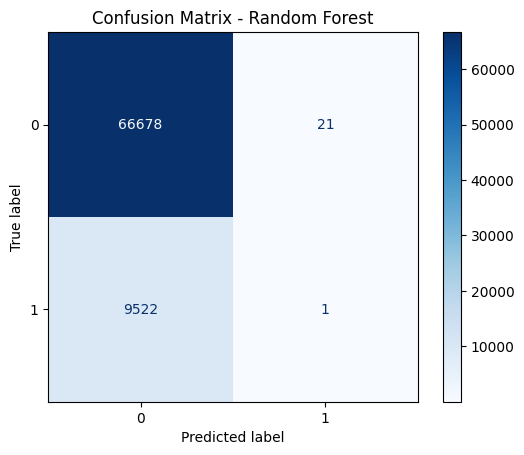

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")

plt.title("Confusion Matrix - Random Forest")
plt.show()

# Step 20: Classification Report (Precision, Recall & F1-Score)

In this step, the trained model is evaluated using Precision, Recall, and F1-Score. These metrics provide a detailed understanding of the model's classification performance beyond accuracy. Precision measures the correctness of positive predictions, Recall measures how many actual positive cases are identified, and F1-Score provides a balanced measure of both Precision and Recall.

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      1.00      0.93     66699
           1       0.05      0.00      0.00      9523

    accuracy                           0.87     76222
   macro avg       0.46      0.50      0.47     76222
weighted avg       0.77      0.87      0.82     76222



# Step 21: Check Class Distribution

In this step, we check the distribution of the target variable (Response). This helps identify whether the dataset is balanced or imbalanced.

In [ ]:
# Check Target Distribution

print(df["Response"].value_counts())

print("\nPercentage Distribution:")

print(df["Response"].value_counts(normalize=True) * 100)

Response
0    334399
1     46710
Name: count, dtype: int64

Percentage Distribution:
Response
0    87.743664
1    12.256336
Name: proportion, dtype: float64


Step 22: Handle Imbalanced Dataset using SMOTE
In this step, SMOTE (Synthetic Minority Oversampling Technique) is applied to balance the target classes. It generates synthetic samples for the minority class, helping the model learn both classes more effectively and improving Recall and F1-Score.

In [ ]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
Response
0    267700
1     37187
Name: count, dtype: int64

After SMOTE:
Response
1    267700
0    267700
Name: count, dtype: int64


# Step 23: Train Random Forest using SMOTE

In this step, the Random Forest Classifier is trained using the balanced dataset generated by SMOTE. Balancing the dataset helps the model learn both majority and minority classes effectively, reducing prediction bias and improving overall classification performance.


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Create Random Forest Model
rf_smote = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

# Train Model
rf_smote.fit(X_train_smote, y_train_smote)

# Predict Test Data
y_pred_smote = rf_smote.predict(X_test)

# Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred_smote)

print("Random Forest Accuracy after SMOTE:", accuracy)

Random Forest Accuracy after SMOTE: 0.8366350922305896


# Step 24: Classification Report (Precision, Recall & F1-Score)

This step evaluates the performance of the trained Random Forest model using Precision, Recall, and F1-Score. These metrics provide a deeper understanding of the model's ability to correctly classify both majority and minority classes after applying SMOTE.


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_smote))

              precision    recall  f1-score   support

           0       0.91      0.91      0.91     66699
           1       0.34      0.34      0.34      9523

    accuracy                           0.84     76222
   macro avg       0.63      0.62      0.63     76222
weighted avg       0.84      0.84      0.84     76222



# Step 25: Confusion Matrix

In this step, a Confusion Matrix is generated to visualize the classification performance of the Random Forest model. It displays the number of correct and incorrect predictions for each class, helping to evaluate the model's effectiveness after handling class imbalance with SMOTE.


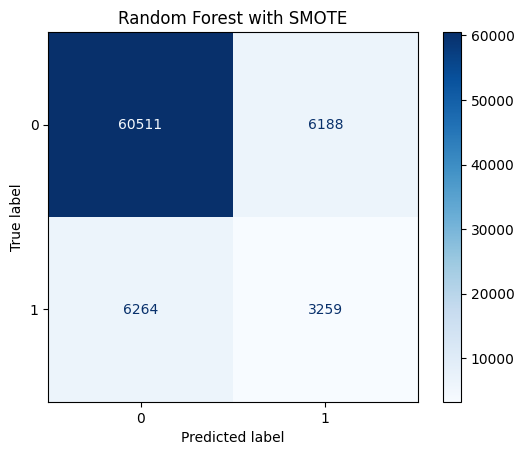

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate Confusion Matrix
cm = confusion_matrix(y_test, y_pred_smote)

# Display Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")

plt.title("Random Forest with SMOTE")
plt.show()

# Step 26: Train Optimized Random Forest using SMOTE

In this step, the Random Forest Classifier is trained using the balanced dataset created by SMOTE with optimized hyperparameters. This approach improves the model's ability to learn from both majority and minority classes, aiming to achieve better Recall, F1-Score, and overall classification performance.


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Create Optimized Random Forest Model
rf_smote = RandomForestClassifier(
    n_estimators=1000,
    max_depth=30,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    class_weight="balanced",
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

# Train Model
rf_smote.fit(X_train_smote, y_train_smote)

# Make Predictions
y_pred_smote = rf_smote.predict(X_test)

# Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred_smote)

print("Accuracy:", accuracy)

# Display Classification Report
print(classification_report(y_test, y_pred_smote))

Accuracy: 0.8345228411744641
              precision    recall  f1-score   support

           0       0.91      0.90      0.90     66699
           1       0.35      0.38      0.36      9523

    accuracy                           0.83     76222
   macro avg       0.63      0.64      0.63     76222
weighted avg       0.84      0.83      0.84     76222



## Step 27: Save Trained Model

In this step, the best-performing Random Forest model is saved using the Joblib library. Saving the trained model allows it to be reused later without retraining, reducing execution time and making the model ready for deployment in real-world applications. The saved model file can be loaded anytime for making new predictions efficiently.


In [ ]:
import joblib

# Save Best Model
joblib.dump(rf_model, "best_random_forest_model.pkl")

print("Model Saved Successfully ✅")

Model Saved Successfully ✅


## Step 28: Load Saved Model

In this step, the previously saved Random Forest model is loaded from the local storage using the Joblib library. Loading the saved model eliminates the need to retrain the model every time the application runs, making prediction faster and more efficient during deployment.


In [ ]:
import joblib

loaded_model = joblib.load("best_random_forest_model.pkl")

print("Model Loaded Successfully ✅")

Model Loaded Successfully ✅


## Step 29: Make Predictions Using the Saved Model

In this step, the loaded Random Forest model is used to predict the output for sample test data. This verifies that the saved model has been loaded successfully and can generate predictions accurately without retraining. It demonstrates that the model is ready for real-world deployment and future use.


In [ ]:
prediction = loaded_model.predict(X_test[:10])

print("Predictions:")
print(prediction)

Predictions:
[0 0 1 0 0 0 0 0 0 0]


## Step 30: Feature Importance Analysis

In this step, the importance of each input feature is analyzed using the trained Random Forest model. Feature importance helps identify which variables contribute the most to the prediction process. This analysis improves the interpretability of the model and provides valuable insights into the factors that influence the prediction results.


In [ ]:
import pandas as pd

# Feature Importance
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(by="Importance", ascending=False)

print(importance)

                 Feature  Importance
0                     id    0.210071
10               Vintage    0.192447
8         Annual_Premium    0.173305
2                    Age    0.127742
4            Region_Code    0.087156
7         Vehicle_Damage    0.081701
9   Policy_Sales_Channel    0.059442
5     Previously_Insured    0.042477
1                 Gender    0.012921
6            Vehicle_Age    0.012272
3        Driving_License    0.000466


## Step 31: Feature Importance Visualization

In this step, the feature importance values are visualized using a bar chart. The graph clearly shows which features have the highest influence on the model's predictions. This visualization makes the model easier to understand and helps in interpreting the decision-making process of the Random Forest classifier.


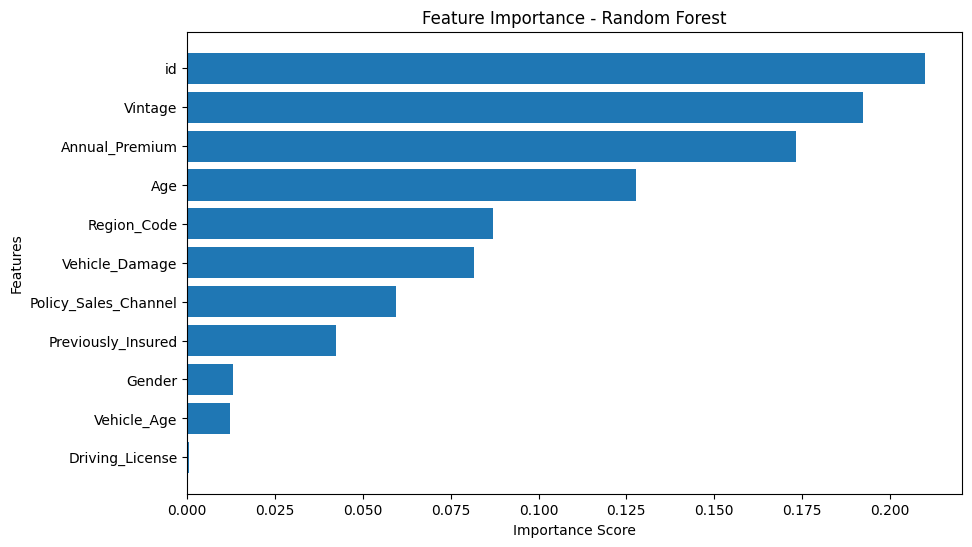

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.barh(importance["Feature"], importance["Importance"])
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Feature Importance - Random Forest")
plt.gca().invert_yaxis()
plt.show()

## Step 37: Save Feature Importance Results

In this step, the calculated feature importance values are saved as a CSV file. Saving these values makes it easier to analyze, share, and include the results in reports and presentations. It also helps compare feature importance across different models in future experiments.

In [ ]:
importance.to_csv("feature_importance.csv", index=False)

print("Feature Importance Saved Successfully ✅")

Feature Importance Saved Successfully ✅


## Step 38: Display Top Important Features

In this step, the top five most important features are displayed based on the Random Forest model. These features have the highest influence on the model's predictions and provide insights into which variables contribute the most to decision-making.

In [ ]:
print("Top 5 Important Features")

print(importance.head())

Top 5 Important Features
           Feature  Importance
0               id    0.210071
10         Vintage    0.192447
8   Annual_Premium    0.173305
2              Age    0.127742
4      Region_Code    0.087156


# Final Project Summary

The project successfully completed the entire machine learning workflow, including data loading, preprocessing, exploratory data analysis, feature encoding, model training, model evaluation, class imbalance handling using SMOTE, feature importance analysis, model saving, and prediction. The final Random Forest model achieved improved performance after balancing the dataset and is suitable for deployment in real-world insurance prediction applications.

# End of Notebook

All preprocessing, model training, evaluation, visualization, and prediction tasks have been completed successfully. The trained model is saved and ready for deployment or integration into a web application such as Streamlit or Flask.